In [ ]:
import numpy as np
import pandas as pd
from ultralytics import YOLO
from pathlib import Path
from collections import defaultdict

# load model
model = YOLO("/home/debasish/Documents/YOLOv8/weights/pose/yolov8l-pose-1024.pt")

# ground truths
video_gt_map = {
    "/home/debasish/Documents/YOLOv8/videos/omega_turns/12fps/image002.mp4": {1: [262]},
    "/home/debasish/Documents/YOLOv8/videos/omega_turns/12fps/image003.mp4": {1: [341]},
    # "/home/debasish/Documents/YOLOv8/videos/omega_turns/12fps/image006.mp4": {1: [249]},
    "/home/debasish/Documents/YOLOv8/videos/omega_turns/12fps/image031.mp4": {1: [155, 187]},
    "/home/debasish/Documents/YOLOv8/videos/omega_turns/12fps/image040.mp4": {1: [56]},
    "/home/debasish/Documents/YOLOv8/videos/omega_turns/12fps/image041.mp4": {1: [246]},
    # "/home/debasish/Documents/YOLOv8/videos/omega_turns/12fps/image047.mp4": {1: [258, 279]},
    "/home/debasish/Documents/YOLOv8/videos/omega_turns/12fps/image048.mp4": {1: [8, 27, 163]},
    "/home/debasish/Documents/YOLOv8/videos/omega_turns/12fps/image050.mp4": {1: [264, 289, 313]},
    # "/home/debasish/Documents/YOLOv8/videos/omega_turns/12fps/image052.mp4": {1: [23]},
    "/home/debasish/Documents/YOLOv8/videos/omega_turns/12fps/image056.mp4": {10: [78, 155]},
}

TOL = 20  # tolerance window

# angle
def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians * 180 / np.pi)
    return 360-angle if angle > 180 else angle

# distance
def end_segment_distance(kpts, k=3):
    if len(kpts) < 2*k:
        return np.inf

    return min(
        np.linalg.norm(h - t)
        for h in kpts[:k]
        for t in kpts[-k:]
    )

# peak extraction
def extract_peaks(flag_series, angle_series):
    peaks = []
    start = None

    for i in range(len(flag_series)):
        frame, flag = flag_series[i]

        if flag == 1 and start is None:
            start = i

        elif flag == 0 and start is not None:
            segment = angle_series[start:i]

            if len(segment) > 0:
                frames = [f for (f, _) in segment]
                angles = [a for (_, a) in segment]
                peak_idx = np.argmin(angles)
                peaks.append(frames[peak_idx])

            start = None

    return peaks

# error
def match_error(pred_peaks, gt_peaks):
    if len(gt_peaks) == 0:
        return 0
    if len(pred_peaks) == 0:
        return 1000

    return np.mean([min(abs(p - g) for p in pred_peaks) for g in gt_peaks])

# TP, FP, FN
def evaluate_peaks(pred_peaks, gt_peaks, tol=10):

    matched = set()
    TP = 0

    for p in pred_peaks:
        for i, g in enumerate(gt_peaks):
            if i in matched:
                continue
            if abs(p - g) <= tol:
                TP += 1
                matched.add(i)
                break

    FP = len(pred_peaks) - TP
    FN = len(gt_peaks) - TP

    return TP, FP, FN

# process video
def run_detection(video_path, k_head, theta, thresh):

    results_gen = model.track(str(video_path), persist=False, tracker="bytetrack.yaml", stream=True, verbose=False)

    angle_series = defaultdict(list)
    flag_series  = defaultdict(list)
    last_state = defaultdict(lambda: "no_omega")

    THRESH = thresh

    for frame_idx, result in enumerate(results_gen):

        if result.orig_img is None:
            continue
        if result.boxes is None or result.keypoints is None:
            continue
        if result.boxes.id is None or result.keypoints.xy is None:
            continue

        ids = result.boxes.id.cpu().numpy()
        kpts_all = result.keypoints.xy.cpu().numpy()

        for i in range(len(ids)):
            track_id = int(ids[i])
            kpts = kpts_all[i]

            if len(kpts) < 6:
                continue

            head = kpts[k_head]
            mid  = kpts[len(kpts)//2]
            tail = kpts[-1]

            angle = calculate_angle(head, mid, tail)

            seg_lengths = np.linalg.norm(np.diff(kpts, axis=0), axis=1)
            L = np.sum(seg_lengths)

            d = end_segment_distance(kpts)
            d_norm = d / L if L > 0 else np.inf

            # CLEAN STATE MACHINE (IMPORTANT)
            if last_state[track_id] == "no_omega":
                if d_norm < THRESH and angle < theta:
                    last_state[track_id] = "omega"
            
            elif last_state[track_id] == "omega":
                if d_norm > THRESH:
                    last_state[track_id] = "no_omega"

            omega_flag = 1 if last_state[track_id] == "omega" else 0

            flag_series[track_id].append((frame_idx, omega_flag))
            angle_series[track_id].append((frame_idx, angle))

    pred_dict = {}
    for track_id in flag_series:
        pred_dict[track_id] = extract_peaks(flag_series[track_id], angle_series[track_id])

    return pred_dict

# evaluation
def evaluate_dataset(video_gt_map, k_head, theta, thresh):

    total_error = 0
    total_events = 0
    TP_total = FP_total = FN_total = 0

    for video_path_str, worm_gt in video_gt_map.items():

        video_path = Path(video_path_str)

        pred_dict = run_detection(video_path, k_head, theta, thresh)

        # consider only GT worms
        for worm_id, gt_peaks in worm_gt.items():

            pred_peaks = pred_dict.get(worm_id, [])

            # error 
            err = match_error(pred_peaks, gt_peaks)
            total_error += err
            total_events += len(gt_peaks)

            # TP, FP, FN 
            TP, FP, FN = evaluate_peaks(pred_peaks, gt_peaks, tol=TOL)

            TP_total += TP
            FP_total += FP
            FN_total += FN

    # metrics calculation
    avg_error = total_error / max(total_events, 1)

    precision = TP_total / (TP_total + FP_total) if (TP_total + FP_total) > 0 else 0
    recall    = TP_total / (TP_total + FN_total) if (TP_total + FN_total) > 0 else 0
    f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0

    print(f"TP={TP_total}, FP={FP_total}, FN={FN_total}")

    return avg_error, TP_total, FP_total, FN_total, precision, recall, f1

# grid search
results = []

k_heads = [0]
thetas = np.arange(30, 70, 5)
threshs = np.linspace(0.15, 0.3, 6)

# k_heads = [0]
# thetas = [45]
# threshs = [0.1]

for k_head in k_heads:
    for theta in thetas:
        for thresh in threshs:

            print(f"Running k={k_head}, theta={theta}, thresh={thresh}")
    
            err, TP, FP, FN, p, r, f1 = evaluate_dataset(video_gt_map, k_head, theta, thresh)
    
            print(f"\nerr={err:.2f}, P={p:.2f}, R={r:.2f}, F1={f1:.2f}\n")
    
            results.append((k_head, theta, thresh, err, TP, FP, FN, p, r, f1))

# save results
df = pd.DataFrame(results, columns=[
    "k_head", "theta", "thresh", "error", "TP", "FP", "FN", "precision", "recall", "f1"
])
df.to_csv("omega_parameters_tuning.csv", index=False)

# best parameters
best = max(results, key=lambda x: x[9])

print("\n==============================")
print("BEST PARAMETERS:")
print(f"k_head = {best[0]}")
print(f"theta  = {best[1]}")
print(f"thresh = {best[2]:.2f}")
print(f"error  = {best[3]:.2f}")
print(f"P={best[7]:.2f}, R={best[8]:.2f}, F1={best[9]:.2f}")

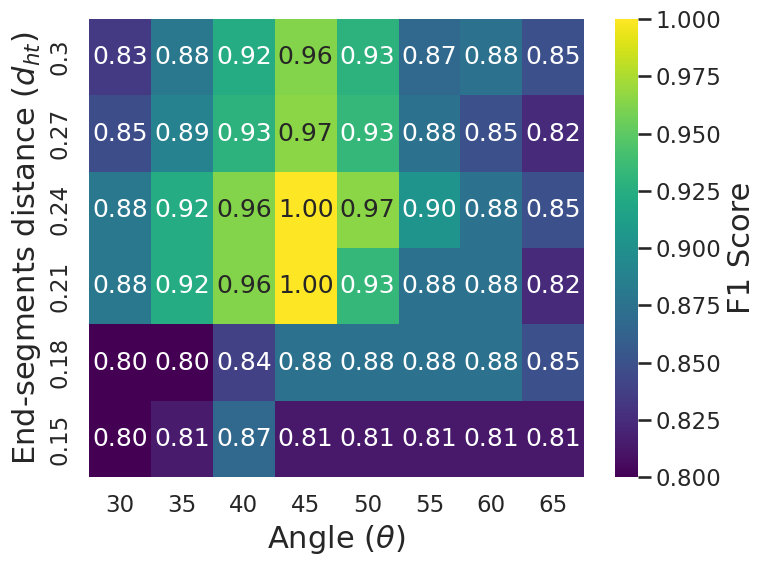

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# load data
df = pd.read_csv("omega_parameters_tuning.csv")  # file path

df["thresh"] = df["thresh"].round(2)

pivot = df.pivot(index="thresh", columns="theta", values="f1")

pivot = pivot.sort_index().sort_index(axis=1)

# plot
plt.figure(figsize=(8,6))
sns.set(style="whitegrid", context="talk")

sns.heatmap(
    pivot,
    annot=True,       # show values
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": "F1 Score"},
)
cbar = plt.gca().collections[0].colorbar
cbar.set_label("F1 Score", fontsize=22)

plt.xlabel("Angle ($\\theta$)", fontsize=22)
plt.ylabel("End-segments distance ($d_{ht}$)", fontsize=22)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()